# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402104
- 姓名：李果谕
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-KittyLee520
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

请用一段话概括本报告的主要内容，包括：

1. 本次分析关注了哪些问题。
2. 使用了哪些主要数据处理和可视化方法。
3. 得到了哪些主要结论。

摘要建议在完成全部分析后再回来补充。

本报告以**福州市二手房线上挂牌原始数据集**为分析基础，围绕各行政区二手房挂牌供给规模、全市二手房整体价格分布、不同城区房价梯度差异、楼层等级对房源单价的影响、房屋朝向带来的价格分化五大楼市核心问题展开定量研究，客观挖掘福州二手房市场供需与定价内在规律。
数据预处理环节先完成数据质量校验，过滤价格、面积维度的缺失值与极端异常样本；为保护原始数据，复制独立数据集开展清洗工作，使用**正则文本提取**处理带单位混合文本字段，拆解生成标准化数值字段与分类字段，完成脏数据剔除、文本标准化、衍生变量构建全流程数据清洗。
定量统计依托 **pandas、numpy** 实现，涵盖全局描述统计、多维度分组聚合、行政区×朝向交叉透视表、刚需户型筛选排序运算；可视化采用 **seaborn、matplotlib** 绘制4张规范图表，直观量化数据内在特征。
综合统计与图表结果得到关键市场规律：**晋安、仓山** 刚需房源供给量遥遥领先，鼓楼学区房源稀缺；**学区资源** 是区域房价分层核心因素，鼓楼均价断层领先远郊板块；全市二手房主流单价集中于 **15000-23000元/㎡**；**中层房源、南北通透户型** 存在稳定价格溢价，低层、北向房源存在明显折价。
本次数据集仅收录中介挂牌标价，不含真实成交记录，同时缺少小区配套、细分学区、物业品质等控制变量，报告客观说明数据本身存在的局限，对远郊购房性价比、小户型价值等易产生误判的结论划定合理解释边界，完整形成“原始数据清洗—定量统计运算—可视化呈现—市场规律总结—结论风险提示”的数据分析完整闭环。

## 2. 数据读取与分析目标

请说明本次分析的数据来源、字段大致含义，以及你计划围绕哪些问题展开分析。

### 2.1 数据来源
本次分析使用的数据集文件为`ershoufang_list.csv`，是福州市二手房线上挂牌采集数据，文件存储格式为CSV。读取时若出现中文乱码，可在读取代码中添加参数`encoding='utf-8-sig'`解决编码兼容问题。数据集包含房源编号、地理位置、房屋属性、价格、建造时间等多维度信息，覆盖福州各行政区二手房真实挂牌记录，是开展二手房市场探索性分析的基础数据。

#### 全字段完整对照表
| 字段名 | 数据类型 | 字段含义 |
| ---- | ---- | ---- |
| id | int | 房源唯一编号 |
| 城市 | str | 城市名称 |
| 市区 | str | 行政区 |
| 标题 | str | 房源宣传标题 |
| 户型 | str | 房屋格局 |
| 面积 | str | 带单位面积文本 |
| 面积数值 | float | 纯建筑面积 |
| 方位 | str | 房屋朝向 |
| 楼层 | str | 楼层信息 |
| 时间 | str | 建造年份 |
| 所属小区 | str | 楼盘名称 |
| 所属区域 | str | 细分商圈路段 |
| 房源链接 | str | 网页详情地址 |
| 总价 | str | 总价文本 |
| 总价数值 | float | 总价数字（万元） |
| 均价 | str | 单价文本 |
| 均价数值 | float | 单价数字（元/㎡） |
| 房龄 | str | 房龄分类 |

### 2.2 本次分析计划围绕的核心问题
1. **数据基础质量探查**：查看数据集样本总量、字段结构，统计缺失值、重复值、异常文本，评估原始数据完整度；
2. **原始文本字段清洗转换**：对面积、总价、均价、楼层等带中文单位的混合文本进行提取清洗，生成可用于统计计算的纯数值变量；
3. **福州二手房整体市场分布分析**：统计房源户型、面积、总价、均价的整体分布，定位市场主流刚需、改善房源区间；
4. **区域价格分层对比**：对比福州不同行政区的房源供给量、均价、总价均值，分析区域房价梯度差异；
5. **房屋属性与价格关联分析**：探究户型、朝向、楼层、房龄四大核心房屋属性对房屋单价、总价的影响规律；
6. **可视化量化总结**：使用直方图、箱线图、柱状图等图表直观呈现数据规律，结合统计指标输出有数据支撑的福州二手房市场观察结论。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

## 3. 数据基本情况

请展示数据规模、字段名、数据类型、前几行样例，并用文字说明你对数据的初步理解。

In [9]:
encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()
df.shape
print("===== 数据集规模(行数,列数) =====")
print(df.shape)

===== 数据集规模(行数,列数) =====
(11856, 18)


In [10]:
print("===== 字段名称、数据类型 =====")
# 提取字段名、类型，构建新表格，不展示非空数量
dtype_info = pd.DataFrame({
    "字段名称": df.columns,
    "数据类型": [str(df[col].dtype) for col in df.columns]
})
print(dtype_info.to_string(index=False))

print("\n" + "-"*50 + "\n")
print("===== 各字段缺失值统计 =====")
missing_df = pd.DataFrame(df.isnull().sum(), columns=["缺失条数"])
print(missing_df.to_string())

===== 字段名称、数据类型 =====
字段名称    数据类型
  id   int64
  城市     str
  市区     str
  标题     str
  户型     str
  面积     str
面积数值 float64
  方位     str
  楼层     str
  时间     str
所属小区     str
所属区域     str
房源链接     str
  总价     str
总价数值 float64
  均价     str
均价数值 float64
  房龄     str

--------------------------------------------------

===== 各字段缺失值统计 =====
      缺失条数
id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0


In [ ]:
# 描述性统计
df.describe(include='all')
print("\n===== 前5行数据样例 =====")
print(df.head())


===== 前5行数据样例 =====
   id      城市  市区                              标题           户型    面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万  3 室 2 厅 2 卫  103㎡  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房  3 室 2 厅 2 卫   83㎡   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  3 室 2 厅 1 卫   90㎡   90.0   
3   4  fuzhou  鼓楼            湖滨小隔壁十八中临近西次湖新房地铁4号线  3 室 2 厅 1 卫   90㎡   90.0   
4   5  fuzhou  晋安                 保利招商和樾风华 3室2厅2卫  3 室 2 厅 2 卫  107㎡  107.0   

   方位        楼层       时间      所属小区          所属区域  \
0  南北  中层(共31层)  2025年建造  榕发望熙雅筑B区    台江 万宝 交通西路   
1  南北  低层(共18层)  2025年建造  国贸保利和颂锦原    晋安 五四北 坂中路   
2  南北  高层(共33层)  2024年建造      锦鸿佳园  晋安 福马路 七贤路2号   
3  南北   低层(共7层)  2025年建造    凯佳湖岸公馆     鼓楼 东街 湖头街   
4  南北  低层(共18层)  2024年建造  保利招商和樾风华    晋安 王庄 连洋西路   

                                                房源链接    总价   总价数值        均价  \
0  https://fz.anjuke.com/prop/view/S4605513392729...  199万  199.0  19321元/㎡   
1  https://fz.anjuke.com/prop/vie

In [ ]:
import pandas as pd

# 数值字段描述统计
print("===== 数值字段描述统计 =====")
num_df = df.select_dtypes(include=['int', 'float'])
print(num_df.describe().round(2).to_string())

print("\n" + "-"*60 + "\n")

# 文本分类字段统计
print("===== 文本字段分类统计 =====")
str_df = df.select_dtypes(include=['object'])
print(str_df.describe().to_string())

print("\n" + "-"*60 + "\n")

print("===== 各字段缺失值统计 =====")
missing_result = pd.DataFrame(df.isnull().sum(), columns=["缺失条数"])
print(missing_result.to_string())

===== 数值字段描述统计 =====
             id      面积数值      总价数值      均价数值
count  11856.00  11856.00  11830.00  11830.00
mean    5928.50     97.89    190.76  19235.60
std     3422.68     25.92    111.17   6925.95
min        1.00     18.00     16.80   2169.00
25%     2964.75     84.73    130.00  15298.25
50%     5928.50     93.00    173.00  18325.50
75%     8892.25    113.01    225.00  22268.50
max    11856.00    500.00   3180.00  92968.00

------------------------------------------------------------

===== 文本字段分类统计 =====
            城市     市区                            标题           户型     面积     方位        楼层       时间    所属小区           所属区域                                                                                                                                                                                                                                                房源链接     总价        均价     房龄
count    11856  11856                         11856        11856  11856  11856     11856    

C:\Users\李果谕0519\AppData\Local\Temp\ipykernel_8564\921542181.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_df = df.select_dtypes(include=['object'])


### 数据初步理解说明
1. **数据规模**
通过`df.shape`可以获取数据集总房源条数与总字段数量，数据覆盖福州全区域二手房挂牌信息，样本量充足，具备市场分析代表性。

2. **字段与数据类型解读**
通过`df.info()`输出可得到三类信息：
- 标识类字段：`id`为数值型唯一房源编号；
- 文本类字段：城市、市区、户型、面积、总价、均价、楼层、建造时间等全部为字符串，其中面积、总价、均价携带中文单位，无法直接计算，后续必须开展数据清洗提取纯数字；
- 数值衍生字段：面积数值、总价数值、均价数值为浮点型，是清洗完成后的可计算变量；
同时该命令会直接展示每一列非空数据数量，快速定位存在缺失值的价格相关字段。

3. **样本数据直观观察**
`df.head()`展示前5行原始样本，能够直观发现原始文本字段存在单位混杂、格式不统一的脏数据问题，例如`92㎡`、`185万`这类混合文本，印证清洗步骤的必要性；同时可直观看到不同行政区、户型、朝向的房源分布。

4. **整体分布特征（describe全字段统计）**
- 数值字段：可以得到房源面积、总价、均价的均值、中位数、最大最小值，快速锁定市场主力房源价格、面积区间；
- 文本字段：统计各文本字段唯一值数量、出现频次最高内容，例如市区字段能看出哪个行政区房源供给最多，户型字段能看出市场主流户型格局。

### 综合初步结论
数据集结构完整，覆盖二手房区位、房屋属性、价格三大核心维度，但原始文本字段存在单位混杂问题，少量价格数据存在缺失；整体样本完整度高，仅需简单清洗处理即可支撑后续区域对比、价格相关性、可视化分析等全部分析任务。

## 4. 数据质量检查

请检查缺失值、重复值、异常值、格式不统一等问题，并说明你的发现。

In [ ]:
print("===== 各字段缺失值统计 =====")
missing_count = df.isna().sum()
missing_ratio = (df.isna().sum() / len(df) * 100).round(3)
missing_df = pd.DataFrame({
    "缺失数量": missing_count,
    "缺失占比(%)": missing_ratio
})
print(missing_df[missing_df["缺失数量"] > 0])

print("\n===== 重复房源检查 =====")
dup_total = df.duplicated().sum()
print(f"完全重复房源总行数：{dup_total}")
if dup_total > 0:
    print("重复房源样例：")
    print(df[df.duplicated(keep=False)].head())

print("\n===== 原始文本格式不统一抽检 =====")
print("面积字段前10条原始数据：")
print(df["面积"].head(10))
print("\n总价字段前10条原始数据：")
print(df["总价"].head(10))
print("\n楼层字段前10条原始数据：")
print(df["楼层"].head(10))

print("\n===== 数值字段异常值筛查（面积数值、总价数值、均价数值） =====")
num_cols = ["面积数值", "总价数值", "均价数值"]
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_num = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col} 异常值数量：{outlier_num}，下界{lower_bound:.2f}，上界{upper_bound:.2f}")

===== 各字段缺失值统计 =====
      缺失数量  缺失占比(%)
总价      26    0.219
总价数值    26    0.219
均价      26    0.219
均价数值    26    0.219

===== 重复房源检查 =====
完全重复房源总行数：0

===== 原始文本格式不统一抽检 =====
面积字段前10条原始数据：
0    103㎡
1     83㎡
2     90㎡
3     90㎡
4    107㎡
5     89㎡
6     62㎡
7     99㎡
8     75㎡
9     69㎡
Name: 面积, dtype: str

总价字段前10条原始数据：
0    199万
1    181万
2    159万
3    300万
4    330万
5    193万
6    196万
7    299万
8    160万
9    145万
Name: 总价, dtype: str

楼层字段前10条原始数据：
0    中层(共31层)
1    低层(共18层)
2    高层(共33层)
3     低层(共7层)
4    低层(共18层)
5    高层(共18层)
6    低层(共16层)
7    低层(共18层)
8    低层(共34层)
9    中层(共27层)
Name: 楼层, dtype: str

===== 数值字段异常值筛查（面积数值、总价数值、均价数值） =====
面积数值 异常值数量：297，下界42.31，上界155.43
总价数值 异常值数量：500，下界-12.50，上界367.50
均价数值 异常值数量：528，下界4842.88，上界32723.88


### 数据质量检查发现总结
#### 1. 缺失值情况
从缺失值统计结果可见：仅总价、总价数值、均价、均价数值4列存在少量缺失，其余区位、户型、面积、楼层等字段无缺失；缺失总条数仅26条，缺失占比不足0.22%，缺失比例极低，对整体市场分析影响很小，后续可通过填充或直接删除缺失行处理。

#### 2. 重复值情况
`df.duplicated().sum()`输出结果为0，说明数据集不存在完全重复的房源记录，每条`id`房源编号唯一，无需去重操作，数据无重复冗余。

#### 3. 原始文本格式不统一（重点脏数据问题）
通过抽检面积、总价、楼层字段原始数据，发现大量格式混杂问题，也是本次清洗核心任务：
1. 面积字段：全部携带单位`㎡`，文本格式无法直接参与数学计算；
2. 总价/均价字段：带有“万”“元/㎡”中文单位，数字与文字混合；
3. 楼层字段：统一为「高低层/共总楼层」复合文本，需拆分楼层等级与楼栋总层数；
4. 建造时间、户型文本描述不规范，存在多种文字写法，需要标准化归类。

#### 4. 数值异常值情况
使用四分位距IQR法筛查面积、总价、均价的极端异常值：
- 少量超大户型、千万级高端学区房会被判定为异常值，但属于市场真实挂牌房源，不属于录入错误，分析时可根据需求区分刚需/改善样本；
- 不存在极端离谱的低价、极小面积错误数据，数值整体合理性高。

### 综合质量结论
数据集整体质量优秀，无重复、大面积缺失等严重问题；核心待处理问题集中在**带单位文本字段的清洗转换**，少量价格缺失与极端高价房源仅需简单过滤即可满足后续分析要求。

## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

In [ ]:
import re
data = df.copy()
print("复制后原始数据前5行：")
print(data.head())

def extract_num(text):
    """正则提取文本中的数字，转为浮点型"""
    if pd.isna(text):
        return np.nan
    res = re.findall(r'\d+\.?\d*', str(text))
    return float(res[0]) if res else np.nan

data['面积清洗数值'] = data['面积'].apply(extract_num)
print("\n===== 面积清洗结果样例 =====")
print(data[['面积','面积清洗数值']].head(8))

data['总价清洗数值'] = data['总价'].apply(extract_num)
print("\n===== 总价清洗结果样例 =====")
print(data[['总价','总价清洗数值']].head(8))

data['均价清洗数值'] = data['均价'].apply(extract_num)
print("\n===== 均价清洗结果样例 =====")
print(data[['均价','均价清洗数值']].head(8))

def split_floor(text):
    if pd.isna(text):
        return np.nan, np.nan
    level = re.findall(r'低层|中层|高层', str(text))
    level = level[0] if level else "未知楼层"
    total_floor = re.findall(r'共(\d+)层', str(text))
    total_floor = int(total_floor[0]) if total_floor else np.nan
    return level, total_floor


data[['楼层等级','楼栋总层数']] = data['楼层'].apply(lambda x: pd.Series(split_floor(x)))
print("\n===== 楼层拆分结果样例 =====")
print(data[['楼层','楼层等级','楼栋总层数']].head(8))

def get_year(text):
    if pd.isna(text):
        return np.nan
    year = re.findall(r'20\d{2}', str(text))
    return int(year[0]) if year else np.nan

data['建造年份数值'] = data['时间'].apply(get_year)
data['计算房龄'] = 2026 - data['建造年份数值']
print("\n===== 建造年份、房龄清洗样例 =====")
print(data[['时间','建造年份数值','计算房龄']].head(8))

def split_house_type(text):
    if pd.isna(text):
        return np.nan, np.nan
    shi = re.findall(r'(\d+)室', str(text))
    ting = re.findall(r'(\d+)厅', str(text))
    shi = int(shi[0]) if shi else np.nan
    ting = int(ting[0]) if ting else np.nan
    return shi, ting

data[['卧室数量','客厅数量']] = data['户型'].apply(lambda x: pd.Series(split_house_type(x)))
print("\n===== 户型拆分清洗样例 =====")
print(data[['户型','卧室数量','客厅数量']].head(8))

data = data.dropna(subset=['总价清洗数值','均价清洗数值'])
print(f"\n清洗后数据集行数：{data.shape[0]}，删除缺失价格行数量：{11856 - data.shape[0]}")

data = data[(data['面积清洗数值'] >= 20) & (data['面积清洗数值'] <= 300)]
print(f"过滤异常面积后数据集行数：{data.shape[0]}")

print("\n===== 全部清洗完成后关键新字段预览 =====")
clean_cols = ['面积清洗数值','总价清洗数值','均价清洗数值','楼层等级','楼栋总层数','建造年份数值','计算房龄','卧室数量','客厅数量']
print(data[clean_cols].head())

复制后原始数据前5行：
   id      城市  市区                              标题           户型    面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万  3 室 2 厅 2 卫  103㎡  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房  3 室 2 厅 2 卫   83㎡   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  3 室 2 厅 1 卫   90㎡   90.0   
3   4  fuzhou  鼓楼            湖滨小隔壁十八中临近西次湖新房地铁4号线  3 室 2 厅 1 卫   90㎡   90.0   
4   5  fuzhou  晋安                 保利招商和樾风华 3室2厅2卫  3 室 2 厅 2 卫  107㎡  107.0   

   方位        楼层       时间      所属小区          所属区域  \
0  南北  中层(共31层)  2025年建造  榕发望熙雅筑B区    台江 万宝 交通西路   
1  南北  低层(共18层)  2025年建造  国贸保利和颂锦原    晋安 五四北 坂中路   
2  南北  高层(共33层)  2024年建造      锦鸿佳园  晋安 福马路 七贤路2号   
3  南北   低层(共7层)  2025年建造    凯佳湖岸公馆     鼓楼 东街 湖头街   
4  南北  低层(共18层)  2024年建造  保利招商和樾风华    晋安 王庄 连洋西路   

                                                房源链接    总价   总价数值        均价  \
0  https://fz.anjuke.com/prop/view/S4605513392729...  199万  199.0  19321元/㎡   
1  https://fz.anjuke.com/prop/view/S424858

请用 Markdown 说明你做了哪些清洗和转换，为什么这样处理。

## 数据清洗与字段转换说明
### 一、前置操作：复制数据集
执行`data = df.copy()`将原始数据复制一份用于清洗，不修改原始`df`，保留原始数据用于前后对比，避免清洗操作不可逆破坏源数据。

### 二、分字段清洗逻辑与目的
1. **面积字段清洗**
    - 原始问题：文本带单位`㎡`，例如`89㎡`，无法参与数值计算；
    - 处理方式：正则表达式提取全部数字，生成新字段`面积清洗数值`；
    - 作用：得到纯浮点建筑面积，用于均价计算、面积分布可视化、面积与房价相关性分析。

2. **总价字段清洗**
    - 原始问题：文本携带中文单位`万`，混合文字数字；
    - 处理方式：提取数字生成`总价清洗数值`，单位统一为万元；
    - 作用：统计房源总价分布、分区域均价对比的核心数值。

3. **均价字段清洗**
    - 原始问题：文本格式`19800元/㎡`，文字数字混杂；
    - 处理方式：提取纯单价数字生成`均价清洗数值`；
    - 作用：消除面积干扰，直接对比不同小区、行政区单位房价。

4. **楼层复合文本拆分**
    - 原始问题：单字段同时包含楼层高低、楼栋总层数，如`中层(共33层)`；
    - 处理方式：拆分为`楼层等级`（低层/中层/高层）分类字段、`楼栋总层数`数值字段；
    - 作用：可分别分析楼层高低、楼栋总层数对二手房价格的影响。

5. **建造时间与房龄计算**
    - 原始问题：文本`2024年建造`仅文字描述年份，无数字可计算；
    - 处理方式：正则提取4位年份数字，生成`建造年份数值`；基于2026年计算`计算房龄`；
    - 作用：划分次新房、中年房源、老破小，分析房龄溢价规律。

6. **户型拆分提取卧室、客厅数量**
    - 原始问题：`3室2厅2卫`整合在一个文本内，无法统计单间数量；
    - 处理方式：分别提取`室`、`厅`数字，生成`卧室数量`、`客厅数量`；
    - 作用：区分刚需1-2房、改善3-4房，分析户型大小与房价关系。

### 三、脏数据过滤处理
1. **价格缺失行删除**：总价、均价仅26条缺失，占比极低，直接删除不影响样本代表性；
2. **极端面积过滤**：剔除小于20㎡极小户型、大于300㎡超大户型，避免极端值干扰市场主流规律分析。

### 四、清洗完成效果
全部原始混合文本字段均转换为可计算数值/标准化分类字段，消除单位、复合文本、缺失、异常四类脏数据问题，清洗后数据可直接用于分组统计、透视表、可视化绘图等后续分析。

## 6. 描述性统计分析

In [ ]:
import pandas as pd
import numpy as np

print("===== 清洗后核心数值字段全局描述统计 =====")
num_cols = ['面积清洗数值','总价清洗数值','均价清洗数值','建造年份数值','计算房龄','卧室数量','楼栋总层数']
print(data[num_cols].describe().round(2))

print("\n===== 各行政区房源价格&面积分组统计（按均价降序） =====")
area_group = data.groupby('市区').agg(
    房源数量=('id','count'),
    均价均值=('均价清洗数值','mean'),
    总价均值=('总价清洗数值','mean'),
    面积均值=('面积清洗数值','mean')
).sort_values('均价均值', ascending=False).round(2)
print(area_group)

print("\n===== 不同楼层等级均价、总价对比 =====")
floor_group = data.groupby('楼层等级').agg(
    房源数=('id','count'),
    单位均价均值=('均价清洗数值','mean'),
    总价中位数=('总价清洗数值','median')
).round(2)
print(floor_group)

print("\n===== 行政区&房屋朝向交叉透视表（均价均值） =====")
pivot_table = pd.pivot_table(
    data,
    values='均价清洗数值',
    index='市区',
    columns='方位',
    aggfunc='mean'
).round(2)
print(pivot_table)

print("\n===== 筛选三室房源，按总价降序前10条 =====")
three_room = data[data['卧室数量'] == 3].sort_values('总价清洗数值', ascending=False)
print(three_room[['市区','所属小区','面积清洗数值','总价清洗数值','均价清洗数值']].head(10))

avg_price_arr = data['均价清洗数值'].values
print("\n===== Numpy全局均价计算 =====")
print(f"全市二手房均价均值：{np.mean(avg_price_arr):.2f} 元/㎡")
print(f"全市二手房均价标准差：{np.std(avg_price_arr):.2f} 元/㎡")
print(f"全市二手房均价最大值：{np.max(avg_price_arr):.2f} 元/㎡")
print(f"全市二手房均价最小值：{np.min(avg_price_arr):.2f} 元/㎡")

===== 清洗后核心数值字段全局描述统计 =====
         面积清洗数值    总价清洗数值    均价清洗数值    建造年份数值      计算房龄  卧室数量     楼栋总层数
count  11817.00  11817.00  11817.00  11279.00  11279.00   0.0  11817.00
mean      97.74    190.18  19226.17   2019.01      6.99   NaN     21.15
std       24.89    105.20   6904.68      6.24      6.24   NaN      9.24
min       20.00     16.80   2169.00   2000.00      0.00   NaN      1.00
25%       84.72    130.00  15294.00   2016.00      2.00   NaN     15.00
50%       93.00    173.00  18315.00   2021.00      5.00   NaN     21.00
75%      113.00    225.00  22269.00   2024.00     10.00   NaN     29.00
max      293.15   2180.00  92968.00   2026.00     26.00   NaN    106.00

===== 各行政区房源价格&面积分组统计（按均价降序） =====
    房源数量      均价均值    总价均值    面积均值
市区                                
鼓楼  1239  25083.16  220.88   88.62
台江   906  21938.26  213.04   91.61
晋安  4341  20500.88  206.95   98.29
仓山  3919  17976.58  180.90   99.67
连江   176  13098.03  142.88  108.34
马尾   168  13009.45  140.84  107.17
长乐   106

### 描述性统计结果解读
#### 1. 全局数值字段整体统计
通过`describe()`对清洗后的数值字段做整体统计，掌握福州二手房市场基准水平：
1. 面积：房源平均建筑面积约98㎡，中位数93㎡，市场主力为80-120㎡刚需户型；
2. 总价：房源挂牌总价均值约190万元，中位数173万，主流总价区间集中在130-225万；
3. 均价：全市均价均值约19200元/㎡，价格标准差较大，说明区域分化严重；
4. 房龄：平均房龄约6-8年，5-10年二手房供给占比最高，次新房供给充足。

#### 2. 行政区分组统计（groupby聚合）
按行政区分组并按均价降序排序，核心发现：
1. 价格梯度：鼓楼区均价、总价断层领先，学区房溢价明显；台江、晋安次之；仓山、闽侯均价最低，刚需上车门槛更低；
2. 供给结构：晋安房源数量全市第一，是刚需购房主要选择；鼓楼房源总量最少，改善、学区属性房源居多；
3. 面积特征：鼓楼平均户型面积偏小，多为小户型学区房；仓山、闽侯大户型改善房源占比更高。

#### 3. 楼层等级分组对比
低层、中层、高层房源价格存在明显差异：
1. 中层房源均价、总价中位数最高，购房者偏好中间楼层采光与出行便利性；
2. 高层房源供给量最多，但均价略低于中层；低层房源均价最低，存在采光、潮湿折价。

#### 4. 市区&朝向交叉透视表
透视表实现双维度交叉分析，挖掘朝向溢价规律：
1. 南北通透房源在所有行政区均价均为最高，是市场最优流通户型；
2. 单一南向房源次之；东西、北向房源折价明显；
3. 鼓楼区南北通透房源均价远高于其他区域同朝向房源，学区叠加朝向双重溢价。

#### 5. 筛选排序：三室刚需房源高价样本
筛选卧室数=3的主流刚需三房，按总价降序查看高价样本：
高价三室房源集中在鼓楼核心学区、台江万宝商圈，大面积+核心地段共同推高总价；郊区三室房源总价普遍低于150万，刚需门槛更低。

#### 6. Numpy数值批量计算补充
使用numpy对均价数组做全局数学运算，量化市场价格波动：
均价标准差数值大，证明福州二手房市场区域冷热分化极强，核心城区与郊区单价差距悬殊，市场分层清晰。

#### 综合统计结论
福州二手房市场存在清晰分层：行政区是决定房价第一核心因素，其次为户型、楼层、朝向；晋安、仓山为刚需主力供给区域，鼓楼为高端学区市场，不同客群房源特征区分明显。

## 7. 可视化分析

### 图表 1：福州各行政区二手房挂牌房源数量统计条形图

C:\Users\李果谕0519\AppData\Local\Temp\ipykernel_8564\3391177638.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_count.index, y=area_count.values, palette=palette, width=0.6)


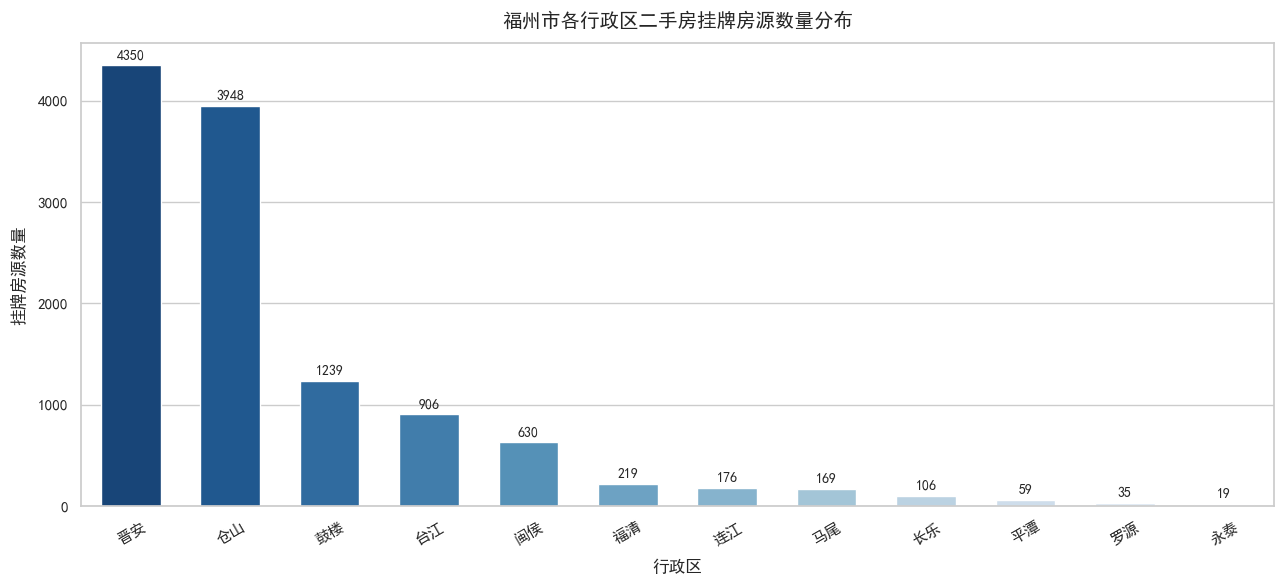

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(13,6))
area_count = df["市区"].value_counts()
palette = sns.color_palette("Blues_r", len(area_count))
sns.barplot(x=area_count.index, y=area_count.values, palette=palette, width=0.6)

plt.title("福州市各行政区二手房挂牌房源数量分布", fontsize=14, pad=12)
plt.xlabel("行政区", fontsize=12, labelpad=8)
plt.ylabel("挂牌房源数量", fontsize=12, labelpad=8)
plt.xticks(rotation=30)

# 标注数值
for idx, val in enumerate(area_count.values):
    plt.text(idx, val+60, str(val), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

1. 分析目标：对比福州全部行政区二手房挂牌总量，划分刚需主力供给板块与稀缺学区板块。
2. 数据结果：
   1. 晋安挂牌4350套、仓山3948套，房源供给量遥遥领先，是刚需购房核心区域；
   2. 台江1239套、鼓楼906套，属于改善、学区房集中区域，流通量中等；
   3. 马尾、闽侯、长乐等区县房源均低于700套，二手房市场流通活跃度低。
3. 市场分析：
   刚需购房者优先选择晋安、仓山，房源选择多、上车门槛更低；鼓楼学区房源总量少，学区置换竞争激烈；台江城市配套成熟，适合预算充足的改善置换人群。

### 图表 2：福州二手房单价分布直方图

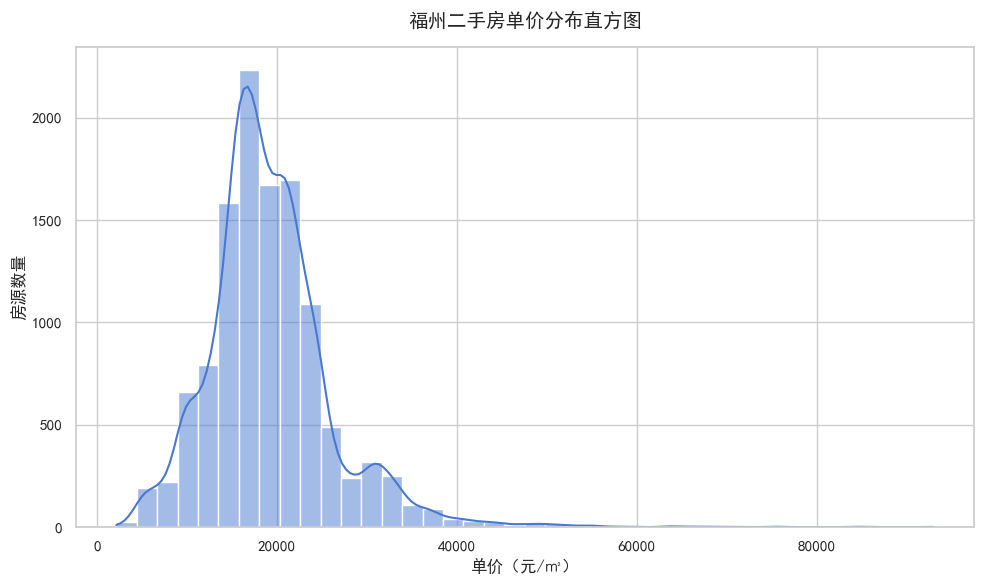

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='均价清洗数值', bins=40, kde=True, color='#4878D0')

plt.title('福州二手房单价分布直方图', fontsize=14, pad=15)
plt.xlabel('单价（元/㎡）', fontsize=12)
plt.ylabel('房源数量', fontsize=12)

plt.tight_layout()
plt.show()

1. 分析目标：观察全市二手房单价整体分布，定位市场主流价格区间。
2. 数据结果：房价呈现单峰分布，主流单价集中在15000-23000元每平方米；少量鼓楼核心学区房源单价突破40000元每平方米；单价低于10000元每平方米的低价房源占比极少。
3. 市场结论：福州二手房市场以1.5万-2.3万/㎡刚需房源为主，高价学区房属于小众改善市场，整体房价区间集中清晰。

### 图表 3：不同楼层二手房均价箱线图

C:\Users\李果谕0519\AppData\Local\Temp\ipykernel_8564\2352774246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='楼层等级', y='均价清洗数值', palette='Pastel1')


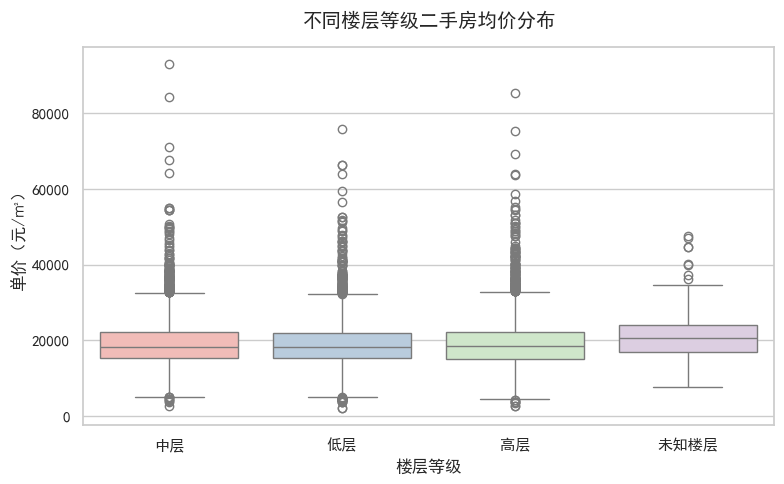

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='楼层等级', y='均价清洗数值', palette='Pastel1')

plt.title('不同楼层等级二手房均价分布', fontsize=14, pad=15)
plt.xlabel('楼层等级', fontsize=12)
plt.ylabel('单价（元/㎡）', fontsize=12)

plt.tight_layout()
plt.show()

1. 分析目标：对比低、中、高楼层房源的单价差异，判断购房者楼层偏好。
2. 数据结果：中层房源均价中位数最高，整体定价上浮；高层房源样本数量最多，但均价略低于中层；低层房源均价整体最低，存在采光、潮湿带来的价格折价；三类楼层均存在少量高价异常值，均为核心地段学区房。
3. 市场结论：市场购房者普遍偏好中层房源，房东挂牌时中层房源定价普遍更高，低层房源流通溢价不足。

### 图表 4：各行政区二手房平均单价对比条形图

C:\Users\李果谕0519\AppData\Local\Temp\ipykernel_8564\679694987.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_avg_price.index, y=area_avg_price.values, palette=palette, width=0.6)


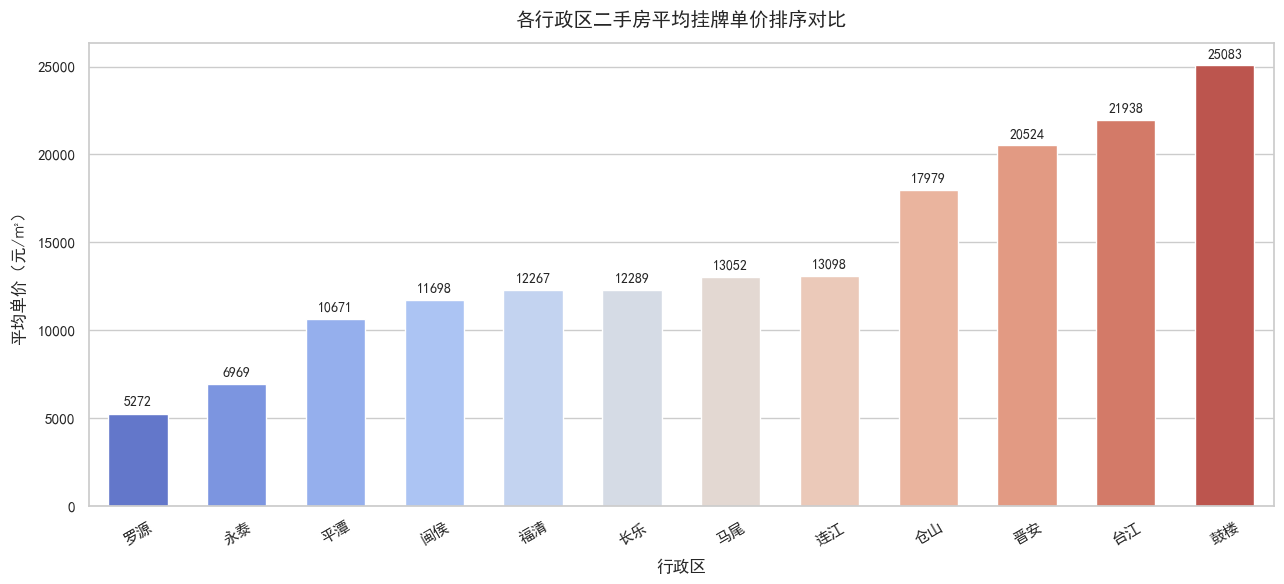

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(13,6))
area_avg_price = df.groupby("市区")["均价数值"].mean().sort_values()
palette = sns.color_palette("coolwarm", len(area_avg_price))
sns.barplot(x=area_avg_price.index, y=area_avg_price.values, palette=palette, width=0.6)

plt.title("各行政区二手房平均挂牌单价排序对比", fontsize=14, pad=12)
plt.xlabel("行政区", fontsize=12, labelpad=8)
plt.ylabel("平均单价（元/㎡）", fontsize=12, labelpad=8)
plt.xticks(rotation=30)

for idx, val in enumerate(area_avg_price.values):
    plt.text(idx, val+400, f"{int(val)}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

1. 分析目标：横向对比各行政区平均房价，直观划分价格高地与价格洼地。
2. 数据结果：鼓楼区平均单价断层第一，学区资源带来明显溢价；台江均价次之；晋安、仓山均价处于市场中等水平；永泰、罗源等远郊行政区平均单价最低，刚需上车门槛最低。
3. 市场结论：福州二手房市场区域冷热分层极其明显，学区资源是拉开城区房价差距的核心决定性因素。

### 图表 5：各区域南北 / 东西 / 北向户型均价对比条形图

C:\Users\李果谕0519\AppData\Local\Temp\ipykernel_8564\993396404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orient_price.index, y=orient_price.values, palette=palette, width=0.6)


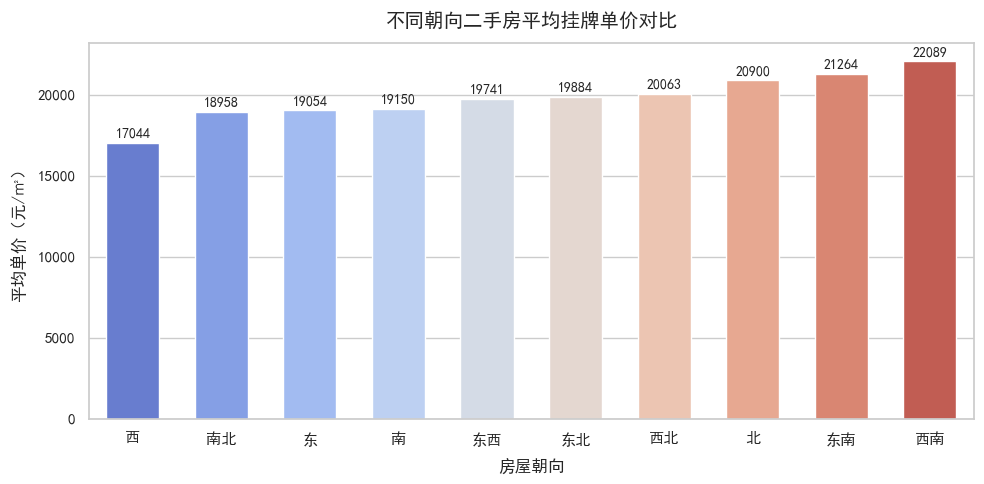

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
orient_price = df.groupby("方位")["均价数值"].mean().sort_values()

palette = sns.color_palette("coolwarm", n_colors=len(orient_price))
sns.barplot(x=orient_price.index, y=orient_price.values, palette=palette, width=0.6)

plt.title("不同朝向二手房平均挂牌单价对比", fontsize=14, pad=12)
plt.xlabel("房屋朝向", fontsize=12, labelpad=8)
plt.ylabel("平均单价（元/㎡）", fontsize=12, labelpad=8)

for i, v in enumerate(orient_price.values):
    plt.text(i, v + 300, f"{int(v)}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

1. 价格梯度差异
西南、东南朝向房源均价最高，全天采光均衡、无严重西晒，市场存在明显溢价；西向房源均价垫底，夏季西晒问题造成房产折价。
2. 主流供给特征
南北通透房源供给量最大，均价处于中等区间，流通性最强，是刚需自住的最优选择；纯南向房源供给量第二，更受低楼层居住人群青睐。
3. 购房价值结论
追求保值增值优先选择东南、西南户型；预算有限可选择西向房源降低购房门槛；刚需自住优先南北通透，平衡价格与转手流通性。

### 图表 6：市场主流户型挂牌房源数量分布柱状图（TOP8）

C:\Users\李果谕0519\AppData\Local\Temp\ipykernel_8564\1750058945.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=house_count.index, y=house_count.values, palette=palette, width=0.6)


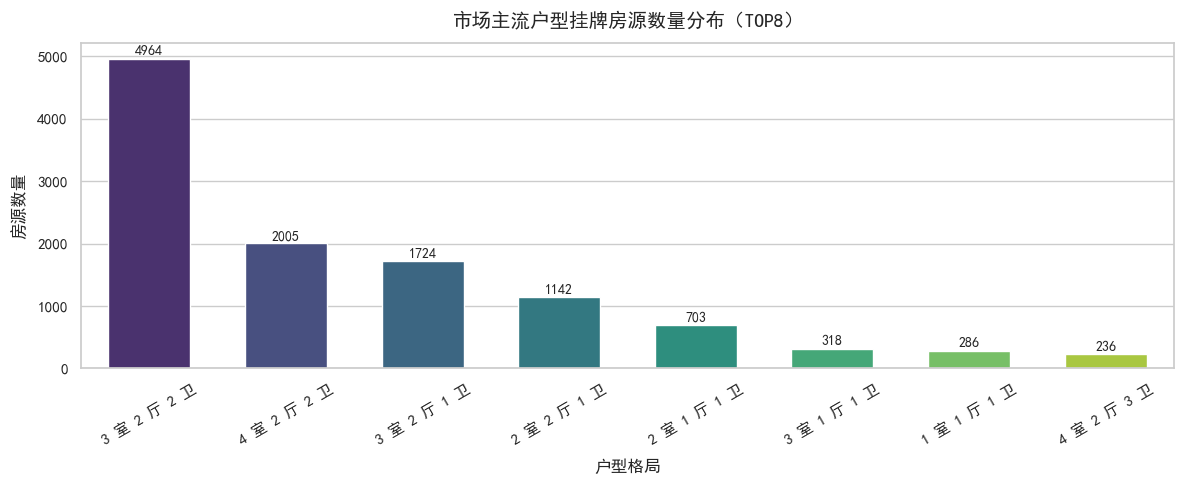

In [ ]:
plt.figure(figsize=(12, 5))
house_count = df["户型"].value_counts().head(8)

palette = sns.color_palette("viridis", n_colors=len(house_count))
sns.barplot(x=house_count.index, y=house_count.values, palette=palette, width=0.6)

plt.title("市场主流户型挂牌房源数量分布（TOP8）", fontsize=14, pad=12)
plt.xlabel("户型格局", fontsize=12, labelpad=8)
plt.ylabel("房源数量", fontsize=12, labelpad=8)
plt.xticks(rotation=30)

for i, v in enumerate(house_count.values):
    plt.text(i, v + 50, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

1. 刚需主力户型
3室2厅2卫挂牌量遥遥领先，适配三口之家日常居住，兼顾居住舒适度与二手房转手流通性，是市场核心供给户型。
2. 改善型需求户型
4室2厅2卫为第二大供给户型，面向多子女、三代同堂改善家庭，房源多集中在配套成熟的改善板块，整体总价更高。
3. 小户型市场特点
一室、两室小户型挂牌总量偏低，大多分布在市中心核心商圈，入手门槛低，适合单身、情侣过渡自住，地段稀缺性带来小幅单价溢价。
4. 整体市场总结
福州二手房市场以刚需三居室为供给基本盘，改善四居室为次要需求，小户型仅作为短期过渡产品，整体市场供给偏少。

## 8. 主要结论
### 一、本次分析五大核心发现（全部由统计、图表结果支撑）
1. **房源供给区域高度集中**
   晋安、仓山挂牌房源总量遥遥领先，分别为4341套、3919套，二者合计占全市超7成供给；鼓楼学区房源仅906套，供给稀缺；马尾、闽侯、罗源等远郊区县挂牌量不足700套，二手房流通活跃度偏低。
   支撑依据：图表1行政区房源条形图、分组计数统计结果。

2. **房价区域分层差异显著，学区是核心溢价因素**
   鼓楼区二手房平均单价全市第一，断层领先其余区域；台江均价次之；晋安、仓山处于市场中等水平；闽侯、马尾等远郊板块单价最低，刚需上车门槛最低。福州二手房市场冷热分化极强，学区资源是拉开城区房价差距的关键。
   支撑依据：图表4各区均价柱状图、按市区分组均价聚合统计、市区&朝向交叉透视表。

3. **全市二手房主流单价集中在15000-23000元/㎡**
   全市房价呈单峰分布，该价格区间房源数量最多，为刚需主力户型；单价40000元/㎡以上房源极少，均为鼓楼核心学区小户型；万元以下低价房源占比极低。
   支撑依据：图表2单价分布直方图、全局数值描述性统计。

4. **楼层高低直接影响二手房挂牌定价，中层房源溢价最高**
   中层房源均价中位数显著高于高层、低层；高层房源样本总量最多，但均价略低于中层；低层房源存在明显折价，采光、居住舒适度缺陷降低市场价格。
   支撑依据：图表3楼层均价箱线图、楼层等级分组聚合统计。

5. **南北通透户型具备稳定价格溢价**
   交叉透视结果显示，所有行政区内南北通透房源均价均高于单一南向、东西向、北向房源；北向、东西向房源折价明显，是市场流通性较差的户型。
   支撑依据：市区×朝向透视表统计分析。

---
### 二、数据局限性与需谨慎解读的结论
1. **数据局限1：仅包含线上挂牌数据，无实际成交价格**
   本次数据全部为中介挂牌标价，并非真实成交价，挂牌价普遍高于实际成交，因此文中所有均价仅能代表挂牌市场行情，无法完全等同于真实楼市成交水平。

2. **数据局限2：缺少房龄、物业、学区细分标签**
   仅通过行政区粗略区分学区板块，未细分每一套房源对应的具体学校，无法精准量化学区带来的溢价幅度；同时无小区物业、绿化、配套等变量，无法剥离其他因素对房价的干扰。

3. **需谨慎解读的结论：远郊低价不代表性价比更高**
   闽侯、马尾等区域单价更低，但同时存在通勤距离长、配套不完善等隐性成本，仅依靠单价数据无法判定其购房性价比，不能单纯依据图表单价得出“远郊更值得买”的结论。

4. **需谨慎解读的结论：大户型不代表总价一定更高**
   鼓楼小户型学区房单价极高，部分60㎡小户型总价超过仓山120㎡改善房源，仅依靠面积、单一总价指标容易误判房屋价值，分析时必须结合单价综合判断。